# Max-gap / Jenks batch-adaptive thresholds on the lexical grounder

**Author**: Konrad Jelen (kj)<br>
**Date**: 2026-06-10

The shipped lexical manifold classifies each claim independently against a fixed threshold.
The pre-fork cascade instead derived a per-batch threshold from the score distribution's gap
structure (`adaptive_gap`) and scored 0.93 macro-F1 on the article fixtures where the manifold
scores 0.81. This experiment applies the same unsupervised cut to the manifold's `p_high`
probabilities, one batch per sub-dataset kind (private_rag / vitaminc / articles), and compares
three cut variants against the fixed-threshold baseline.

Hypothesis + falsifiers: `experiments/grounding/HYPOTHESIS.md` (batch-adaptive operating point).
Dataset: `data/processed/grounding_combined.parquet` (gitignored; built by
`experiments/grounding/build_combined.py`).

## Imports

In [1]:
# stdlib
import sys
from pathlib import Path

# data handling
import numpy as np
import pandas as pd

# breaks / classification
import jenkspy                              # Jenks natural breaks (2-class cut)
from sklearn.metrics import f1_score        # macro-F1 scoring

# plotting
import matplotlib.pyplot as plt

# rich output
from rich.console import Console
from rich.table import Table

console = Console()

# experiment modules (repo-root relative)
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "experiments/grounding"))
import build_combined as BC                 # combined dataset builder + shipped manifold

## Configuration

In [2]:
# ---- experiment configuration ----------------------------------------------
REFRESH_DATASET = False                     # True -> rebuild parquet (~6 min, 24 workers)
MIN_BATCH = 4                               # gap cut needs >= 4 claims, else fixed threshold
GAP_FLOOR_SWEEP = [0.0, 0.02, 0.05, 0.10, 0.15]  # gap-significance floors to sweep
KNOWN_BASELINES = {                         # sanity gate: fixed threshold must reproduce these
    "private_rag": 0.817,                   # joint logistic macro-F1 (SOTA doc)
    "vitaminc": 0.691,
    "articles": 0.8075,                     # bench_lexical.py mean macro-F1 (2026-06-10)
}
SANITY_TOL = 0.06                           # tolerance: thresholds here are shipped, not per-corpus tuned

cfg = Table(title="Experiment configuration")
cfg.add_column("setting"); cfg.add_column("value")
cfg.add_row("dataset", str(BC.OUT_PARQUET.relative_to(REPO)))
cfg.add_row("refresh", str(REFRESH_DATASET))
cfg.add_row("batch unit", "corpus (sub-dataset kind)")
cfg.add_row("min batch size", str(MIN_BATCH))
cfg.add_row("gap floor sweep", str(GAP_FLOOR_SWEEP))
console.print(cfg)

                   Experiment configuration                    
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ setting         ┃ value                                     ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dataset         │ data/processed/grounding_combined.parquet │
│ refresh         │ False                                     │
│ batch unit      │ corpus (sub-dataset kind)                 │
│ min batch size  │ 4                                         │
│ gap floor sweep │ [0.0, 0.02, 0.05, 0.1, 0.15]              │
└─────────────────┴───────────────────────────────────────────┘

## Data loading

Build-or-load the combined parquet (2,752 private_rag + 800 vitaminc + 42 articles rows, HIGH-tier features + shipped-manifold `p_high`).

In [3]:
df = BC.build(refresh=REFRESH_DATASET)
lv = BC.shipped_manifold("high")

t = Table(title=f"Combined dataset - {len(df)} rows, shipped high threshold {lv.threshold}")
t.add_column("corpus"); t.add_column("rows", justify="right")
t.add_column("supported", justify="right"); t.add_column("hallucination", justify="right")
t.add_column("groups", justify="right")
for corpus, g in df.groupby("corpus"):
    t.add_row(corpus, str(len(g)), str(int(g.label.sum())), str(int((1 - g.label).sum())),
              str(g.group_id.nunique()))
console.print(t)

 Combined dataset - 3594 rows, shipped high threshold 0.4  
┏━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ corpus      ┃ rows ┃ supported ┃ hallucination ┃ groups ┃
┡━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ articles    │   42 │        36 │             6 │      3 │
│ private_rag │ 2752 │      1966 │           786 │    639 │
│ vitaminc    │  800 │       400 │           400 │      1 │
└─────────────┴──────┴───────────┴───────────────┴────────┘

## Strategies

Four operating points applied to the same `p_high` column. The gap cuts mirror the cascade's `adaptive_gap` guards: batch >= 4 else fixed, optional gap-significance floor with fallback to fixed.

In [4]:
def cut_maxgap(probs: np.ndarray, bottom_half: bool = False) -> tuple[float, float]:
    """Largest-gap midpoint threshold; returns (threshold, gap size)."""
    x = np.sort(probs)
    diffs = np.diff(x)
    if bottom_half:
        limit = max(2, (len(x) + 1) // 2)       # cascade's variant: search bottom half only
        diffs = diffs[:min(len(diffs), limit)]
    j = int(np.argmax(diffs))
    return (x[j] + x[j + 1]) / 2, float(diffs[j])


def cut_jenks(probs: np.ndarray) -> tuple[float, float]:
    """Jenks 2-class break; returns (threshold, gap at the break)."""
    x = np.sort(probs)
    brk = jenkspy.jenks_breaks(x, n_classes=2)[1]   # [min, break, max]
    below = x[x <= brk]
    above = x[x > brk]
    gap = float(above.min() - below.max()) if len(below) and len(above) else 0.0
    thr = (below.max() + above.min()) / 2 if len(below) and len(above) else brk
    return thr, gap


def tuned_fixed(probs: np.ndarray, labels: np.ndarray) -> float:
    """Label-tuned per-corpus fixed threshold (supervised reference upper bound)."""
    grid = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(labels, probs >= t, average="macro", zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])


def apply_strategy(probs, labels, strategy, gap_floor=0.0):
    """Return (predictions, threshold_used, gap) for one batch under one strategy."""
    if strategy == "fixed" or len(probs) < MIN_BATCH:
        return probs >= lv.threshold, lv.threshold, np.nan
    if strategy == "tuned":
        thr = tuned_fixed(probs, labels)
        return probs >= thr, thr, np.nan
    if strategy == "maxgap":
        thr, gap = cut_maxgap(probs)
    elif strategy == "maxgap_bottom":
        thr, gap = cut_maxgap(probs, bottom_half=True)
    elif strategy == "jenks":
        thr, gap = cut_jenks(probs)
    else:
        raise ValueError(strategy)
    if gap < gap_floor:                          # insignificant gap -> fall back to fixed
        return probs >= lv.threshold, lv.threshold, gap
    return probs >= thr, thr, gap

## Sanity gate

The fixed baseline must reproduce the known macro-F1 numbers before anything else is interpreted.

In [5]:
sanity = Table(title="Sanity gate - fixed shipped threshold vs known baselines")
sanity.add_column("corpus"); sanity.add_column("macro-F1 here", justify="right")
sanity.add_column("known", justify="right"); sanity.add_column("status")
sane = True
for corpus, g in df.groupby("corpus"):
    f1 = f1_score(g.label, g.p_high >= lv.threshold, average="macro", zero_division=0)
    known = KNOWN_BASELINES[corpus]
    ok = abs(f1 - known) <= SANITY_TOL
    sane &= ok
    sanity.add_row(corpus, f"{f1:.4f}", f"{known:.3f}",
                   "[green]OK[/green]" if ok else "[red]MISMATCH[/red]")
console.print(sanity)
assert sane, "fixed baseline does not reproduce known numbers - pipeline is wrong, stop"


 Sanity gate - fixed shipped threshold vs known 
                   baselines                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ corpus      ┃ macro-F1 here ┃ known ┃ status ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ articles    │        0.7971 │ 0.807 │ OK     │
│ private_rag │        0.8294 │ 0.817 │ OK     │
│ vitaminc    │        0.6950 │ 0.691 │ OK     │
└─────────────┴───────────────┴───────┴────────┘

## Execution - strategy comparison per corpus batch

In [6]:
STRATEGIES = ["fixed", "tuned", "maxgap", "maxgap_bottom", "jenks"]
results = []
for corpus, g in df.groupby("corpus"):
    probs, labels = g.p_high.to_numpy(), g.label.to_numpy()
    fixed_pred = probs >= lv.threshold
    for strat in STRATEGIES:
        pred, thr, gap = apply_strategy(probs, labels, strat)
        results.append({
            "corpus": corpus, "strategy": strat,
            "macro_f1": f1_score(labels, pred, average="macro", zero_division=0),
            "threshold": thr, "gap": gap,
            "flips_vs_fixed": int((pred != fixed_pred).sum()),
        })
res = pd.DataFrame(results)

t = Table(title="Macro-F1 per corpus per strategy (batch = corpus)")
t.add_column("strategy")
for corpus in sorted(df.corpus.unique()):
    t.add_column(corpus, justify="right")
t.add_column("mean", justify="right")
for strat in STRATEGIES:
    row = res[res.strategy == strat].set_index("corpus")
    vals = [row.loc[c, "macro_f1"] for c in sorted(df.corpus.unique())]
    style = "bold" if strat in ("maxgap", "maxgap_bottom", "jenks") else ""
    t.add_row(strat, *[f"{v:.4f}" for v in vals], f"{np.mean(vals):.4f}", style=style)
console.print(t)

t2 = Table(title="Threshold placement and verdict flips vs fixed")
t2.add_column("corpus"); t2.add_column("strategy"); t2.add_column("threshold", justify="right")
t2.add_column("gap", justify="right"); t2.add_column("flips", justify="right")
for _, r in res.iterrows():
    t2.add_row(r.corpus, r.strategy, f"{r.threshold:.4f}",
               "-" if np.isnan(r.gap) else f"{r.gap:.4f}", str(r.flips_vs_fixed))
console.print(t2)

      Macro-F1 per corpus per strategy (batch = corpus)       
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ strategy      ┃ articles ┃ private_rag ┃ vitaminc ┃   mean ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ fixed         │   0.7971 │      0.8294 │   0.6950 │ 0.7738 │
│ tuned         │   0.9028 │      0.8306 │   0.7022 │ 0.8118 │
│ maxgap        │   0.8156 │      0.4190 │   0.3456 │ 0.5268 │
│ maxgap_bottom │   0.8156 │      0.4190 │   0.6761 │ 0.6369 │
│ jenks         │   0.7619 │      0.7938 │   0.6968 │ 0.7508 │
└───────────────┴──────────┴─────────────┴──────────┴────────┘

       Threshold placement and verdict flips vs fixed       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ corpus      ┃ strategy      ┃ threshold ┃    gap ┃ flips ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ articles    │ fixed         │    0.4000 │      - │     0 │
│ articles    │ tuned         │    0.3050 │      - │     3 │
│ articles    │ maxgap        │    0.4911 │ 0.1679 │     2 │
│ articles    │ maxgap_bottom │    0.4911 │ 0.1679 │     2 │
│ articles    │ jenks         │    0.6565 │ 0.1286 │     4 │
│ private_rag │ fixed         │    0.4000 │      - │     0 │
│ private_rag │ tuned         │    0.4050 │      - │    11 │
│ private_rag │ maxgap        │    0.0469 │ 0.0135 │   766 │
│ private_rag │ maxgap_bottom │    0.0469 │ 0.0135 │   766 │
│ private_rag │ jenks         │    0.6050 │ 0.0019 │   358 │
│ vitaminc    │ fixed         │    0.4000 │      - │     0 │
│ vitaminc    │ tuned         │    0.4300 │      - │    20 │
│ vitaminc    │ maxgap        │    0.9538 │ 0.0118 │   381 │
│ vitaminc    │ maxgap_bottom │    0.3050 │ 0.0067 │    79 │
│ vitaminc    │ jenks         │    0.4544 │ 0.0079 │    32 │
└─────────────┴───────────────┴───────────┴────────┴───────┘

## Gap-significance floor sweep

Does a fallback floor rescue the gap cuts where the distribution is unimodal?

In [7]:
sweep = []
for floor in GAP_FLOOR_SWEEP:
    for strat in ["maxgap", "maxgap_bottom", "jenks"]:
        f1s = []
        for corpus, g in df.groupby("corpus"):
            pred, _, _ = apply_strategy(g.p_high.to_numpy(), g.label.to_numpy(), strat, gap_floor=floor)
            f1s.append(f1_score(g.label, pred, average="macro", zero_division=0))
        sweep.append({"floor": floor, "strategy": strat, "mean_macro_f1": float(np.mean(f1s))})
sw = pd.DataFrame(sweep).pivot(index="floor", columns="strategy", values="mean_macro_f1")
console.print(sw.round(4).to_string())

strategy   jenks  maxgap  maxgap_bottom
floor                                  
0.00      0.7508  0.5268         0.6369
0.02      0.7621  0.7800         0.7800
0.05      0.7621  0.7800         0.7800
0.10      0.7621  0.7800         0.7800
0.15      0.7738  0.7800         0.7800

## Probability distributions and cut placements

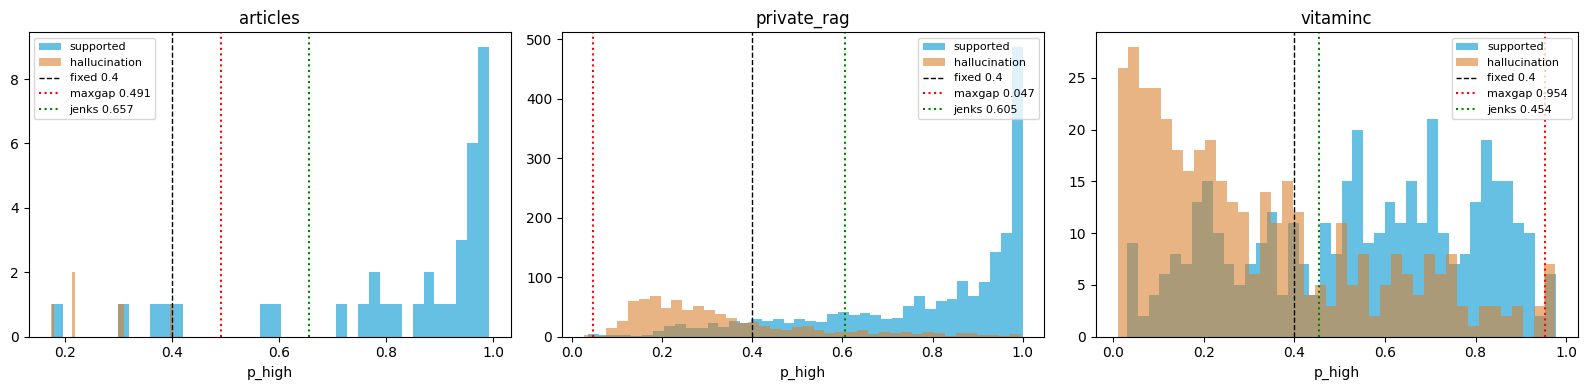

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (corpus, g) in zip(axes, df.groupby("corpus")):
    probs, labels = g.p_high.to_numpy(), g.label.to_numpy()
    ax.hist(probs[labels == 1], bins=40, alpha=0.6, label="supported", color="#0096d1")
    ax.hist(probs[labels == 0], bins=40, alpha=0.6, label="hallucination", color="#da8230")
    ax.axvline(lv.threshold, color="black", ls="--", lw=1, label=f"fixed {lv.threshold}")
    for strat, color in [("maxgap", "red"), ("jenks", "green")]:
        thr = res[(res.corpus == corpus) & (res.strategy == strat)].threshold.iloc[0]
        ax.axvline(thr, color=color, ls=":", lw=1.5, label=f"{strat} {thr:.3f}")
    ax.set_title(corpus); ax.set_xlabel("p_high"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Per-group breakdown (secondary diagnostic)

How the corpus-level cut behaves on finer natural slices (per article, per trace) - and what a per-group cut would have done instead.

In [9]:
rows = []
for (corpus, gid), g in df[df.corpus != "vitaminc"].groupby(["corpus", "group_id"]):
    if len(g) < MIN_BATCH:
        continue
    probs, labels = g.p_high.to_numpy(), g.label.to_numpy()
    if labels.min() == labels.max():
        continue                          # degenerate single-class group, macro-F1 uninformative
    corpus_thr = res[(res.corpus == corpus) & (res.strategy == "maxgap")].threshold.iloc[0]
    grp_thr, _ = cut_maxgap(probs)
    rows.append({
        "corpus": corpus, "group": gid, "n": len(g),
        "f1_fixed": f1_score(labels, probs >= lv.threshold, average="macro", zero_division=0),
        "f1_corpus_cut": f1_score(labels, probs >= corpus_thr, average="macro", zero_division=0),
        "f1_group_cut": f1_score(labels, probs >= grp_thr, average="macro", zero_division=0),
    })
grp = pd.DataFrame(rows)
if len(grp):
    console.print(grp.groupby("corpus")[["f1_fixed", "f1_corpus_cut", "f1_group_cut"]]
                  .mean().round(4).to_string())
    console.print(f"\n[dim]{len(grp)} mixed-label groups with n >= {MIN_BATCH}[/dim]")

f1_fixed  f1_corpus_cut  f1_group_cut
corpus                                            
articles       0.8075         0.8428        0.8428
private_rag    0.6090         0.3132        0.6424

63 mixed-label groups with n >= 4

## Conclusions

**Hypothesis largely falsified at corpus granularity; one transferable signal found.**

- **Raw gap cuts are unsafe on large corpora** - private_rag (maxgap 0.419 vs fixed 0.829) and vitaminc (0.346 vs 0.695): with 800-2,752 dense probabilities the largest gap is noise (gap 0.001-0.013) and the cut lands at an extreme (0.047 / 0.954), flipping 350-770 verdicts
- **The gap-significance floor saves it but neuters it** - any floor in [0.02, 0.15] makes maxgap fall back to fixed everywhere except articles (gap 0.168, genuinely bimodal): mean 0.780 vs fixed 0.774. The only win is the article fixtures - exactly the pre-registered benchmark-overfit falsifier, so corpus-level adoption is rejected
- **Jenks is more stable than raw max-gap but never beats fixed** (0.751 mean unguarded, at best ties vitaminc) - variance-based breaks resist outlier gaps yet still find no real structure in unimodal corpora
- **The genuine signal is small natural batches** - on the 63 mixed-label groups with n >= 4, per-group max-gap cuts beat the fixed threshold: articles 0.843 vs 0.808, private_rag traces 0.642 vs 0.609 (+0.03). This is where the old cascade's adaptive_gap actually lived: per-request batches, not corpora. But most real traces are single-class, where a forced cut is harmful and production cannot know the composition in advance - any follow-up needs an unsupervised guard (gap floor + minimum spread) validated on single-class groups
- **The supervised reference** (label-tuned per-corpus threshold) gains little over shipped fixed (0.812 vs 0.774 mean, mostly articles) - the shipped 0.4 threshold is close to optimal on the training-domain corpora

**Verdict**: do not adopt batch-adaptive thresholds at sub-dataset granularity. The follow-up hypothesis worth testing is per-trace gap cuts gated by a significance floor, scored on ALL traces (mixed and single-class) - rejected unless it holds there.